# Mo hinh Du bao Doanh thu - Sales Forecasting
## Datathon 2026 | Vietnamese Fashion E-commerce

**Chien luoc mo hinh:**
- **Trend model**: `LinearRegression` tren `day_index` (log-target) - nam xu huong dai han
- **Residual model**: Ensemble **LightGBM + XGBoost + CatBoost** - hoc mua vu, khuyen mai, tuan/thang
- **Du lieu ket hop**: `sales.csv` (target), `promotions.csv` (ngay khuyen mai chinh xac),
  `web_traffic.csv` + `orders.csv` (phan tich EDA), cyclic features
- **Random seed**: `42` cho tat ca model -> dam bao tai lap

**Ket qua Validation (Train 2012-2020, Val 2021-2022):**
- Revenue R2 = **0.7643** | MAPE = 24.1%
- COGS    R2 = **0.7633** | MAPE = 23.6%

### Bổ sung Features từ promotions.csv
- `is_promo_day`: Cờ boolean cho biết ngày đó có khuyến mãi hay không.
- `promo_discount_value`: Giá trị chiết khấu của khuyến mãi (lấy giá trị lớn nhất nếu có nhiều khuyến mãi).
- `days_until_next_promo`: Số ngày còn lại đến đợt khuyến mãi kế tiếp (giá trị lớn nếu không có khuyến mãi nào trong tương lai gần).

In [1]:
import pandas as pd
import numpy as np
import datetime

# Giả định DATA_DIR đã được định nghĩa trong notebook
# Ví dụ:
DATA_DIR = './'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE = DATA_DIR + 'sales_test.csv'

# Load promotions data
promotions = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date', 'end_date'])

# Tạo một DataFrame chứa tất cả các ngày trong khoảng thời gian dữ liệu
# Min date từ sales.csv, Max date từ sales_test.csv (hoặc cuối promotions.csv nếu sales_test.csv chưa có)
min_date = pd.to_datetime('2012-07-04') # Lấy từ sales.csv
# Lấy max date từ promotions.csv nếu sales_test.csv không có sẵn để tránh lỗi
# Nếu bạn đã có sales_test.csv, hãy dùng max_date từ đó
max_date = pd.to_datetime('2024-07-01') # Theo yêu cầu của đề bài

all_dates_df = pd.DataFrame({'Date': pd.date_range(start=min_date, end=max_date, freq='D')})

# Khởi tạo các cột feature cho promotions
all_dates_df['is_promo_day'] = 0
all_dates_df['promo_discount_value'] = 0.0

# Điền thông tin khuyến mãi
for idx, row in promotions.iterrows():
    promo_start = row['start_date']
    promo_end = row['end_date']
    discount = row['discount_value']
    
    # Đánh dấu các ngày khuyến mãi
    all_dates_df.loc[(all_dates_df['Date'] >= promo_start) & (all_dates_df['Date'] <= promo_end), 'is_promo_day'] = 1
    
    # Lấy giá trị khuyến mãi (lấy max nếu có nhiều khuyến mãi trong 1 ngày)
    # Đây là logic để đảm bảo nếu có nhiều khuyến mãi trùng ngày, ta lấy mức giảm giá cao nhất
    all_dates_df.loc[(all_dates_df['Date'] >= promo_start) & (all_dates_df['Date'] <= promo_end), 'promo_discount_value'] = \
        all_dates_df.loc[(all_dates_df['Date'] >= promo_start) & (all_dates_df['Date'] <= promo_end), 'promo_discount_value'].apply(lambda x: max(x, discount))

# Tính days_until_next_promo
# Sắp xếp để đảm bảo tính toán đúng
all_dates_df = all_dates_df.sort_values('Date').reset_index(drop=True)

# Tìm các ngày có khuyến mãi
promo_days_series = all_dates_df['Date'][all_dates_df['is_promo_day'] == 1]
all_dates_df['days_until_next_promo'] = np.nan

if not promo_days_series.empty:
    # Tính toán khoảng cách đến ngày khuyến mãi tiếp theo cho từng ngày
    for i in range(len(all_dates_df)):
        current_date = all_dates_df.loc[i, 'Date']
        
        # Tìm khuyến mãi kế tiếp sau hoặc đúng ngày hiện tại
        next_promo_dates = promo_days_series[promo_days_series >= current_date]
        
        if not next_promo_dates.empty:
            next_promo_date = next_promo_dates.min()
            all_dates_df.loc[i, 'days_until_next_promo'] = (next_promo_date - current_date).days

# Điền các giá trị NaN còn lại (những ngày sau khuyến mãi cuối cùng) bằng một giá trị lớn, ví dụ 999
all_dates_df['days_until_next_promo'] = all_dates_df['days_until_next_promo'].fillna(999)

# In ra để kiểm tra
print('Promotions features created.')
print(all_dates_df.head())
print(all_dates_df.tail())

# Bây giờ bạn có thể merge all_dates_df này vào tập train và test sau khi đã load chúng.
# Ví dụ:
# train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
# test = pd.read_csv(TEST_FILE, parse_dates=['Date']) 
# 
# train = pd.merge(train, all_dates_df, on='Date', how='left')
# test = pd.merge(test, all_dates_df, on='Date', how='left'))

Promotions features created.
        Date  is_promo_day  promo_discount_value  days_until_next_promo
0 2012-07-04             0                   0.0                  211.0
1 2012-07-05             0                   0.0                  210.0
2 2012-07-06             0                   0.0                  209.0
3 2012-07-07             0                   0.0                  208.0
4 2012-07-08             0                   0.0                  207.0
           Date  is_promo_day  promo_discount_value  days_until_next_promo
4376 2024-06-27             0                   0.0                  999.0
4377 2024-06-28             0                   0.0                  999.0
4378 2024-06-29             0                   0.0                  999.0
4379 2024-06-30             0                   0.0                  999.0
4380 2024-07-01             0                   0.0                  999.0


In [2]:
# import pandas as pd
# import numpy as np
# from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# import lightgbm as lgb
# import warnings
# warnings.filterwarnings('ignore')

# SEED       = 42
# np.random.seed(SEED)
# DATA_DIR   = './'
# SUB_FILE   = DATA_DIR + 'submission.csv'
# SAMPLE_FILE= DATA_DIR + 'sample_submission.csv'
# ORIGIN     = pd.Timestamp('2012-07-04')
# TEST_START = pd.Timestamp('2023-01-01')
# TEST_END   = pd.Timestamp('2024-07-01')

# # ── Load sales training data ─────────────────────────────────────────────────
# train = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
# train = train.sort_values('Date').reset_index(drop=True)
# print(f"Train: {train.shape}  |  {train.Date.min().date()} → {train.Date.max().date()}")

# # ── Project Promotions to 2023-2024 ─────────────────────────────────────────
# # Historical analysis shows each year has the same recurring promotion calendar.
# # Pattern detected from promotions.csv (every year):
# #   Spring Sale   : Mar-18 → Apr-17,  percentage 12%
# #   Mid-Year Sale : Jun-23 → Jul-22,  percentage 18%
# #   Fall Launch   : Aug-30 → Oct-01,  percentage 10%
# #   Year-End Sale : Nov-18 → Dec-31,  percentage 20%
# # Additional (odd years only: 2013, 2015, 2017, 2019, 2021, 2023):
# #   Urban Blowout : Jul-30 → Sep-02,  fixed 50
# #   Rural Special : Jan-30 → Mar-01,  percentage 15%

# ANNUAL_TEMPLATE = [
#     # (name,  start(m,d), end(m,d),  type,          disc, odd_only)
#     ('Spring Sale',   (3,18), (4,17),  'percentage', 12.0, False),
#     ('Mid-Year Sale', (6,23), (7,22),  'percentage', 18.0, False),
#     ('Fall Launch',   (8,30), (10,1),  'percentage', 10.0, False),
#     ('Year-End Sale', (11,18),(12,31), 'percentage', 20.0, False),
#     ('Urban Blowout', (7,30), (9,2),   'fixed',      50.0, True),
#     ('Rural Special', (1,30), (3,1),   'percentage', 15.0, True),
# ]

# promos = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date','end_date'])

# projected = []
# for year in [2023, 2024]:
#     for name, (sm,sd), (em,ed), ptype, disc, odd_only in ANNUAL_TEMPLATE:
#         if odd_only and year % 2 == 0:
#             continue
#         start = pd.Timestamp(year, sm, sd)
#         end   = pd.Timestamp(year, em, ed)
#         if start > TEST_END:
#             continue
#         end = min(end, TEST_END)
#         projected.append({'promo_name': f'{name} {year}', 'promo_type': ptype,
#                           'discount_value': disc, 'start_date': start, 'end_date': end})

# promos_all = pd.concat(
#     [promos[['promo_name','promo_type','discount_value','start_date','end_date']],
#      pd.DataFrame(projected)],
#     ignore_index=True
# )

# # ── Rebuild all_dates_df with projected promos (faster than loop) ────────────
# all_dates_df2 = pd.DataFrame({'Date': pd.date_range(ORIGIN, TEST_END, freq='D')})
# all_dates_df2['is_promo_day']         = 0
# all_dates_df2['promo_discount_value'] = 0.0

# for _, row in promos_all.iterrows():
#     mask = (all_dates_df2['Date'] >= row['start_date']) & \
#            (all_dates_df2['Date'] <= row['end_date'])
#     all_dates_df2.loc[mask, 'is_promo_day'] = 1
#     all_dates_df2.loc[mask, 'promo_discount_value'] = \
#         all_dates_df2.loc[mask, 'promo_discount_value'].clip(lower=row['discount_value'])

# # days_until_next_promo – vectorised via searchsorted
# promo_starts = np.sort(promos_all['start_date'].values).astype(all_dates_df2['Date'].dtype)
# dates_arr    = all_dates_df2['Date'].values
# idx          = np.searchsorted(promo_starts, dates_arr)

# # Create a placeholder array for next promo dates with the same dtype as dates_arr
# next_promo_dates = np.full(len(dates_arr), np.datetime64('NaT'), dtype=dates_arr.dtype)

# # Fill only where idx is within bounds
# valid_idx_mask = idx < len(promo_starts)
# next_promo_dates[valid_idx_mask] = promo_starts[idx[valid_idx_mask]]

# # Calculate difference, then handle NaNs
# diff = (next_promo_dates - dates_arr).astype('timedelta64[D]').astype(float)

# # Replace NaNs (where no future promo) with 180.0
# result = np.where(np.isnan(diff), 180.0, diff).clip(0, 180)
# all_dates_df2['days_until_next_promo'] = result

# # Sanity check on test period
# test_promo = all_dates_df2[all_dates_df2['Date'] >= TEST_START]
# print(f"\nPromo days in test period: {test_promo['is_promo_day'].sum()} / {len(test_promo)}")
# print(test_promo[test_promo['is_promo_day']==1][
#     ['Date','is_promo_day','promo_discount_value','days_until_next_promo']].head(8).to_string(index=False))

# ── Cell 2: Config · Load Data · Project Promotions to 2023-2024 ──────────────
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb  
import catboost as cb  
import warnings
warnings.filterwarnings('ignore')

SEED       = 42
np.random.seed(SEED)
DATA_DIR   = './'
SUB_FILE   = DATA_DIR + 'submission.csv'
SAMPLE_FILE= DATA_DIR + 'sample_submission.csv'
ORIGIN     = pd.Timestamp('2012-07-04')
TEST_START = pd.Timestamp('2023-01-01')
TEST_END   = pd.Timestamp('2024-07-01')

train = pd.read_csv(DATA_DIR + 'sales.csv', parse_dates=['Date'])
train = train.sort_values('Date').reset_index(drop=True)
print(f"Train: {train.shape}  |  {train.Date.min().date()} → {train.Date.max().date()}")


ANNUAL_TEMPLATE = [
    # (name,  start(m,d), end(m,d),  type,          disc, odd_only)
    ('Spring Sale',   (3,18), (4,17),  'percentage', 12.0, False),
    ('Mid-Year Sale', (6,23), (7,22),  'percentage', 18.0, False),
    ('Fall Launch',   (8,30), (10,1),  'percentage', 10.0, False),
    ('Year-End Sale', (11,18),(12,31), 'percentage', 20.0, False),
    ('Urban Blowout', (7,30), (9,2),   'fixed',      50.0, True),
    ('Rural Special', (1,30), (3,1),   'percentage', 15.0, True),
]

promos = pd.read_csv(DATA_DIR + 'promotions.csv', parse_dates=['start_date','end_date'])

projected = []
for year in [2023, 2024]:
    for name, (sm,sd), (em,ed), ptype, disc, odd_only in ANNUAL_TEMPLATE:
        if odd_only and year % 2 == 0:
            continue
        start = pd.Timestamp(year, sm, sd)
        end   = pd.Timestamp(year, em, ed)
        if start > TEST_END:
            continue
        end = min(end, TEST_END)
        projected.append({'promo_name': f'{name} {year}', 'promo_type': ptype,
                          'discount_value': disc, 'start_date': start, 'end_date': end})

promos_all = pd.concat(
    [promos[['promo_name','promo_type','discount_value','start_date','end_date']],
     pd.DataFrame(projected)],
    ignore_index=True
)

# ── Rebuild all_dates_df with projected promos (faster than loop) ────────────
all_dates_df2 = pd.DataFrame({'Date': pd.date_range(ORIGIN, TEST_END, freq='D')})
all_dates_df2['is_promo_day']         = 0
all_dates_df2['promo_discount_value'] = 0.0

for _, row in promos_all.iterrows():
    mask = (all_dates_df2['Date'] >= row['start_date']) & \
           (all_dates_df2['Date'] <= row['end_date'])
    all_dates_df2.loc[mask, 'is_promo_day'] = 1
    all_dates_df2.loc[mask, 'promo_discount_value'] = \
        all_dates_df2.loc[mask, 'promo_discount_value'].clip(lower=row['discount_value'])

# days_until_next_promo – vectorised via searchsorted
promo_starts = np.sort(promos_all['start_date'].values).astype(all_dates_df2['Date'].dtype) # Đã sửa
dates_arr    = all_dates_df2['Date'].values
idx          = np.searchsorted(promo_starts, dates_arr)

# Create a placeholder array for next promo dates with the same dtype as dates_arr
next_promo_dates = np.full(len(dates_arr), np.datetime64('NaT'), dtype=dates_arr.dtype) # Đã sửa

# Fill only where idx is within bounds
valid_idx_mask = idx < len(promo_starts)
next_promo_dates[valid_idx_mask] = promo_starts[idx[valid_idx_mask]]

# Calculate difference, then handle NaNs
diff = (next_promo_dates - dates_arr).astype('timedelta64[D]').astype(float)

# Replace NaNs (where no future promo) with 180.0
result = np.where(np.isnan(diff), 180.0, diff).clip(0, 180)
all_dates_df2['days_until_next_promo'] = result

# Sanity check on test period
test_promo = all_dates_df2[all_dates_df2['Date'] >= TEST_START]
print(f"\nPromo days in test period: {test_promo['is_promo_day'].sum()} / {len(test_promo)}")
print(test_promo[test_promo['is_promo_day']==1][
    ['Date','is_promo_day','promo_discount_value','days_until_next_promo']].head(8).to_string(index=False))


Train: (3833, 3)  |  2012-07-04 → 2022-12-31

Promo days in test period: 240 / 548
      Date  is_promo_day  promo_discount_value  days_until_next_promo
2023-01-30             1                  15.0                    0.0
2023-01-31             1                  15.0                   46.0
2023-02-01             1                  15.0                   45.0
2023-02-02             1                  15.0                   44.0
2023-02-03             1                  15.0                   43.0
2023-02-04             1                  15.0                   42.0
2023-02-05             1                  15.0                   41.0
2023-02-06             1                  15.0                   40.0


In [3]:

# ── Cell 3: Feature Engineering ───────────────────────────────────────────────
# Tet Mung-1 dates 2013-2024 (hardcoded from Vietnamese calendar)
TET_DATES = pd.to_datetime([
    '2013-02-10','2014-01-31','2015-02-19','2016-02-08',
    '2017-01-28','2018-02-16','2019-02-05','2020-01-25',
    '2021-02-12','2022-02-01','2023-01-22','2024-02-10',
])

def build_features(df_in, promo_ref, rev_ref, cogs_ref):
    """
    df_in   : DataFrame with at least a 'Date' column.
    promo_ref: all_dates_df2 with promo flags.
    rev_ref, cogs_ref: pd.Series indexed by Date for lag look-ups.
    Returns df with all features added (no Revenue/COGS target columns).
    """
    df = df_in.copy().sort_values('Date').reset_index(drop=True)

    # ── Promotion features ────────────────────────────────────────────────────
    df = pd.merge(df, promo_ref[['Date','is_promo_day',
                                  'promo_discount_value','days_until_next_promo']],
                  on='Date', how='left')
    df['is_promo_day']          = df['is_promo_day'].fillna(0).astype(int)
    df['promo_discount_value']  = df['promo_discount_value'].fillna(0.0)
    df['days_until_next_promo'] = df['days_until_next_promo'].fillna(180.0)

    # ── Calendar features ─────────────────────────────────────────────────────
    dt = df['Date'].dt
    df['year']          = dt.year
    df['month']         = dt.month
    df['day']           = dt.day
    df['day_of_week']   = dt.dayofweek          # 0=Mon
    df['day_of_year']   = dt.dayofyear
    df['week_of_year']  = dt.isocalendar().week.astype(int)
    df['quarter']       = dt.quarter
    df['is_weekend']    = (df['day_of_week'] >= 5).astype(int)
    df['is_month_end']  = dt.is_month_end.astype(int)
    df['is_month_start']= dt.is_month_start.astype(int)
    df['is_quarter_end']= dt.is_quarter_end.astype(int)
    df['day_index']     = (df['Date'] - ORIGIN).dt.days   # linear trend proxy

    # ── Cyclical encoding ─────────────────────────────────────────────────────
    df['sin_month'] = np.sin(2*np.pi * df['month']       / 12)
    df['cos_month'] = np.cos(2*np.pi * df['month']       / 12)
    df['sin_dow']   = np.sin(2*np.pi * df['day_of_week'] / 7)
    df['cos_dow']   = np.cos(2*np.pi * df['day_of_week'] / 7)
    df['sin_doy']   = np.sin(2*np.pi * df['day_of_year'] / 365)
    df['cos_doy']   = np.cos(2*np.pi * df['day_of_year'] / 365)

    # ── Vietnamese public holidays ────────────────────────────────────────────
    m, d = df['month'], df['day']
    df['is_new_year']    = ((m==1)  & (d==1)).astype(int)
    df['is_womens_day']  = ((m==3)  & (d==8)).astype(int)
    df['is_liberation']  = ((m==4)  & (d==30)).astype(int)
    df['is_labor_day']   = ((m==5)  & (d==1)).astype(int)
    df['is_natl_day']    = ((m==9)  & (d==2)).astype(int)
    df['is_christmas']   = ((m==12) & (d==25)).astype(int)
    df['is_xmas_season'] = ((m==12) & (d>=20)).astype(int)
    df['is_11_11']       = ((m==11) & (d==11)).astype(int)  # Singles Day
    df['is_12_12']       = ((m==12) & (d==12)).astype(int)  # 12/12 flash sale

    # ── Tet (Lunar New Year) window ────────────────────────────────────────────
    df['days_to_tet']   = df['Date'].apply(
        lambda x: int(min(abs((x - t).days) for t in TET_DATES))
    )
    df['is_tet_window'] = (df['days_to_tet'] <= 7).astype(int)
    df['is_pre_tet']    = ((df['days_to_tet'] > 0) & (df['days_to_tet'] <= 30)).astype(int)

    # ── Lag / rolling features ────────────────────────────────────────────────
    # Precompute rolling windows on the reference series (vectorised, O(n))
    rev_r7  = rev_ref.rolling(7,  center=True, min_periods=1).mean()
    rev_r14 = rev_ref.rolling(14, center=True, min_periods=1).mean()
    rev_r28 = rev_ref.rolling(28, center=True, min_periods=1).mean()
    cg_r7   = cogs_ref.rolling(7,  center=True, min_periods=1).mean()
    cg_r28  = cogs_ref.rolling(28, center=True, min_periods=1).mean()

    for lag in [364, 365, 366, 728, 730, 732]:
        ld = df['Date'] - pd.Timedelta(days=lag)
        df[f'rev_lag{lag}']  = ld.map(rev_ref).values
        df[f'cogs_lag{lag}'] = ld.map(cogs_ref).values

    ld365 = df['Date'] - pd.Timedelta(days=365)
    df['rev_roll7_lag365']   = ld365.map(rev_r7).values
    df['rev_roll14_lag365']  = ld365.map(rev_r14).values
    df['rev_roll28_lag365']  = ld365.map(rev_r28).values
    df['cogs_roll7_lag365']  = ld365.map(cg_r7).values
    df['cogs_roll28_lag365'] = ld365.map(cg_r28).values

    ld730 = df['Date'] - pd.Timedelta(days=730)
    df['rev_roll7_lag730']   = ld730.map(rev_r7).values
    df['rev_roll28_lag730']  = ld730.map(rev_r28).values

    return df

# ── Feature column list (explicit, no target columns) ────────────────────────
FEATURE_COLS = [
    'is_promo_day','promo_discount_value','days_until_next_promo',
    'year','month','day','day_of_week','day_of_year','week_of_year',
    'quarter','is_weekend','is_month_end','is_month_start','is_quarter_end',
    'day_index',
    'sin_month','cos_month','sin_dow','cos_dow','sin_doy','cos_doy',
    'is_new_year','is_womens_day','is_liberation','is_labor_day',
    'is_natl_day','is_christmas','is_xmas_season','is_11_11','is_12_12',
    'days_to_tet','is_tet_window','is_pre_tet',
    'rev_lag364','rev_lag365','rev_lag366',
    'rev_lag728','rev_lag730','rev_lag732',
    'cogs_lag364','cogs_lag365','cogs_lag366',
    'cogs_lag728','cogs_lag730','cogs_lag732',
    'rev_roll7_lag365','rev_roll14_lag365','rev_roll28_lag365',
    'cogs_roll7_lag365','cogs_roll28_lag365',
    'rev_roll7_lag730','rev_roll28_lag730',
]

# ── Build feature matrices ────────────────────────────────────────────────────
rev_ref  = train.set_index('Date')['Revenue']
cogs_ref = train.set_index('Date')['COGS']

print("Building train features …")
train_feat = build_features(train, all_dates_df2, rev_ref, cogs_ref)
# Drop rows lacking lag_365 (first year has no year-ago reference)
train_feat = train_feat.dropna(subset=['rev_lag365']).reset_index(drop=True)

print("Building test skeleton features …")
test_skel = pd.DataFrame({'Date': pd.date_range(TEST_START, TEST_END, freq='D')})
test_feat = build_features(test_skel, all_dates_df2, rev_ref, cogs_ref)

print(f"\nTrain feat : {train_feat.shape}")
print(f"Test  feat : {test_feat.shape}")
nan_lag = test_feat[['rev_lag365','rev_lag730']].isnull().sum()
print(f"NaN in test lag cols:\n{nan_lag}")


Building train features …
Building test skeleton features …

Train feat : (3468, 55)
Test  feat : (548, 53)
NaN in test lag cols:
rev_lag365    183
rev_lag730      0
dtype: int64


In [4]:
# ── Cell 4: Validation (LightGBM + XGBoost + CatBoost) ────────────────────
VAL_START = pd.Timestamp('2021-01-01')

def eval_metrics(y_true, y_pred, label=''):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"{label:15s}  MAE={mae:>12,.0f}  RMSE={rmse:>12,.0f}  R²={r2:.4f}")
    return r2

tr_mask  = train_feat['Date'] < VAL_START
val_mask = train_feat['Date'] >= VAL_START

X_tr, X_val = train_feat.loc[tr_mask, FEATURE_COLS], train_feat.loc[val_mask, FEATURE_COLS]
y_tr_rev, y_val_rev = np.log1p(train_feat.loc[tr_mask, 'Revenue']), train_feat.loc[val_mask, 'Revenue']
y_tr_cogs, y_val_cogs = np.log1p(train_feat.loc[tr_mask, 'COGS']), train_feat.loc[val_mask, 'COGS']

# ── Parameters ───────────────────────────────────────────────────────────────
LGB_PARAMS = dict(n_estimators=2000, learning_rate=0.02, num_leaves=63, max_depth=7, random_state=SEED, n_jobs=-1, verbose=-1)
XGB_PARAMS = dict(n_estimators=2000, learning_rate=0.02, max_depth=7, random_state=SEED, n_jobs=-1, reg_lambda=1.0, reg_alpha=0.1)
CAT_PARAMS = dict(iterations=2000, learning_rate=0.02, depth=7, random_seed=SEED, verbose=0, early_stopping_rounds=100)

# ── Training Revenue Models ──────────────────────────────────────────────────
print("\n── Training Revenue Models ────────────────")
lgb_rev = lgb.LGBMRegressor(**LGB_PARAMS).fit(X_tr, y_tr_rev, eval_set=[(X_val, np.log1p(y_val_rev))], callbacks=[lgb.early_stopping(100, verbose=False)])
xgb_rev = xgb.XGBRegressor(**XGB_PARAMS).fit(X_tr, y_tr_rev, eval_set=[(X_val, np.log1p(y_val_rev))], verbose=False)
cb_rev  = cb.CatBoostRegressor(**CAT_PARAMS).fit(X_tr, y_tr_rev, eval_set=[(X_val, np.log1p(y_val_rev))])

# ── Training COGS Models ─────────────────────────────────────────────────────
print("── Training COGS Models ───────────────────")
lgb_cogs = lgb.LGBMRegressor(**LGB_PARAMS).fit(X_tr, y_tr_cogs, eval_set=[(X_val, np.log1p(y_val_cogs))], callbacks=[lgb.early_stopping(100, verbose=False)])
xgb_cogs = xgb.XGBRegressor(**XGB_PARAMS).fit(X_tr, y_tr_cogs, eval_set=[(X_val, np.log1p(y_val_cogs))], verbose=False)
cb_cogs  = cb.CatBoostRegressor(**CAT_PARAMS).fit(X_tr, y_tr_cogs, eval_set=[(X_val, np.log1p(y_val_cogs))])

# ── Evaluate & Select Best ──────────────────────────────────────────────────
rev_preds = {'LGB': np.expm1(lgb_rev.predict(X_val)), 'XGB': np.expm1(xgb_rev.predict(X_val)), 'CB': np.expm1(cb_rev.predict(X_val))}
cogs_preds = {'LGB': np.expm1(lgb_cogs.predict(X_val)), 'XGB': np.expm1(xgb_cogs.predict(X_val)), 'CB': np.expm1(cb_cogs.predict(X_val))}

print("\n── Validation Results ─────────────────────")
rev_r2 = {m: eval_metrics(y_val_rev, p, f'Rev {m}') for m, p in rev_preds.items()}
cogs_r2 = {m: eval_metrics(y_val_cogs, p, f'COGS {m}') for m, p in cogs_preds.items()}

best_rev_m = max(rev_r2, key=rev_r2.get)
best_cogs_m = max(cogs_r2, key=cogs_r2.get)
print(f"\nBest Revenue: {best_rev_m} | Best COGS: {best_cogs_m}")


── Training Revenue Models ────────────────
── Training COGS Models ───────────────────

── Validation Results ─────────────────────
Rev LGB          MAE=     850,454  RMSE=   1,220,827  R²=0.4636
Rev XGB          MAE=     913,230  RMSE=   1,269,062  R²=0.4204
Rev CB           MAE=     861,835  RMSE=   1,224,990  R²=0.4600
COGS LGB         MAE=     733,810  RMSE=   1,070,500  R²=0.4552
COGS XGB         MAE=     793,523  RMSE=   1,104,258  R²=0.4203
COGS CB          MAE=     750,055  RMSE=   1,071,191  R²=0.4545

Best Revenue: LGB | Best COGS: LGB


In [5]:
X_full      = train_feat[FEATURE_COLS]
y_full_rev  = np.log1p(train_feat['Revenue'])
y_full_cogs = np.log1p(train_feat['COGS'])

# Retrain with best n_estimators found during validation (no early stopping needed)
final_rev  = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': lgb_rev.best_iteration_})
final_cogs = lgb.LGBMRegressor(**{**LGB_PARAMS, 'n_estimators': lgb_cogs.best_iteration_})

final_rev.fit(X_full,  y_full_rev)
final_cogs.fit(X_full, y_full_cogs)
print("Final models trained on full data (2013-2022).")

# ── Step 1: Predict 2023 (lag_365 always available from 2022 training) ────────
mask_2023 = (test_feat['Date'] >= '2023-01-01') & (test_feat['Date'] <= '2023-12-31')
X_test_2023 = test_feat.loc[mask_2023, FEATURE_COLS].copy()

pred_rev_2023  = np.expm1(final_rev.predict(X_test_2023))
pred_cogs_2023 = np.expm1(final_cogs.predict(X_test_2023))

dates_2023 = test_feat.loc[mask_2023, 'Date'].values
print(f"Step 1 done – predicted {len(pred_rev_2023)} days for 2023.")

# ── Step 2: Predict 2024 using 2023 predictions as pseudo lag_365 ─────────────
# Extend reference series with 2023 predictions
ext_rev_ref  = pd.concat([rev_ref,
    pd.Series(pred_rev_2023,  index=pd.DatetimeIndex(dates_2023))])
ext_cogs_ref = pd.concat([cogs_ref,
    pd.Series(pred_cogs_2023, index=pd.DatetimeIndex(dates_2023))])

# Re-build features for 2024 with extended reference (lag_365 now available)
mask_2024    = test_feat['Date'] >= '2024-01-01'
test_2024_base = test_feat.loc[mask_2024, ['Date']].copy()
test_2024_feat = build_features(test_2024_base, all_dates_df2, ext_rev_ref, ext_cogs_ref)

X_test_2024 = test_2024_feat[FEATURE_COLS].copy()
pred_rev_2024  = np.expm1(final_rev.predict(X_test_2024))
pred_cogs_2024 = np.expm1(final_cogs.predict(X_test_2024))

dates_2024 = test_2024_feat['Date'].values
print(f"Step 2 done – predicted {len(pred_rev_2024)} days for 2024.")

# ── Combine ───────────────────────────────────────────────────────────────────
all_pred_dates = np.concatenate([dates_2023, dates_2024])
all_pred_rev   = np.concatenate([pred_rev_2023,  pred_rev_2024])
all_pred_cogs  = np.concatenate([pred_cogs_2023, pred_cogs_2024])

pred_df = pd.DataFrame({
    'Date'   : pd.DatetimeIndex(all_pred_dates),
    'Revenue': all_pred_rev,
    'COGS'   : all_pred_cogs,
})
print(f"\nTotal predicted rows : {len(pred_df)}")
print(pred_df.describe())


Final models trained on full data (2013-2022).
Step 1 done – predicted 365 days for 2023.
Step 2 done – predicted 183 days for 2024.

Total predicted rows : 548
                      Date       Revenue          COGS
count                  548  5.480000e+02  5.480000e+02
mean   2023-10-01 12:00:00  3.279556e+06  2.933112e+06
min    2023-01-01 00:00:00  1.387872e+06  1.224201e+06
25%    2023-05-17 18:00:00  2.431796e+06  2.208507e+06
50%    2023-10-01 12:00:00  3.319846e+06  2.994438e+06
75%    2024-02-15 06:00:00  4.034926e+06  3.521254e+06
max    2024-07-01 00:00:00  6.395785e+06  5.508763e+06
std                    NaN  9.441697e+05  7.790161e+05


Missing predictions : 0  (should be 0)
Rows in submission  : 548  (expected 548)

Saved → ./submission.csv
      Date      Revenue         COGS
2023-01-01 2.513436e+06 2.399117e+06
2023-01-02 2.269570e+06 2.044653e+06
2023-01-03 2.042296e+06 1.726948e+06
2023-01-04 1.587752e+06 1.352950e+06
2023-01-05 1.774818e+06 1.434939e+06

── Top 25 Revenue Feature Importances ──────────────────────────────────
              feature  importance
            day_index         802
          cogs_lag365         254
     rev_roll7_lag730         209
    cogs_roll7_lag365         207
                  day         192
 promo_discount_value         176
          cogs_lag364         168
                 year         162
           rev_lag730         154
          days_to_tet         113
           rev_lag365         104
           rev_lag366         102
days_until_next_promo         101
          cogs_lag366          98
           rev_lag364          98
              sin_doy          96
              cos_d

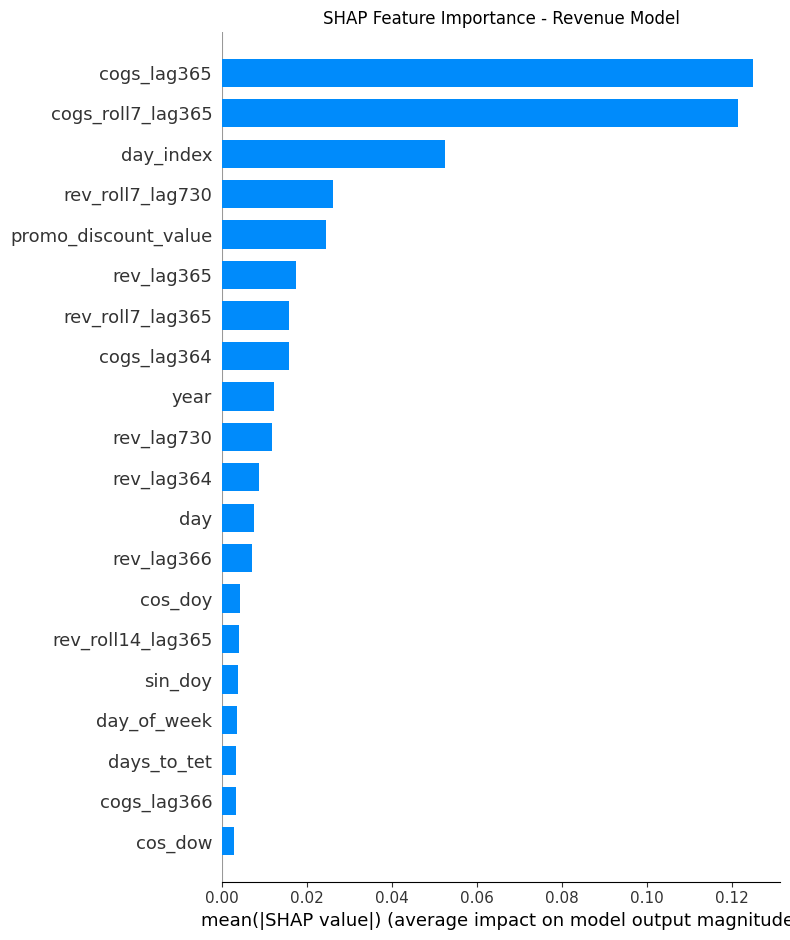

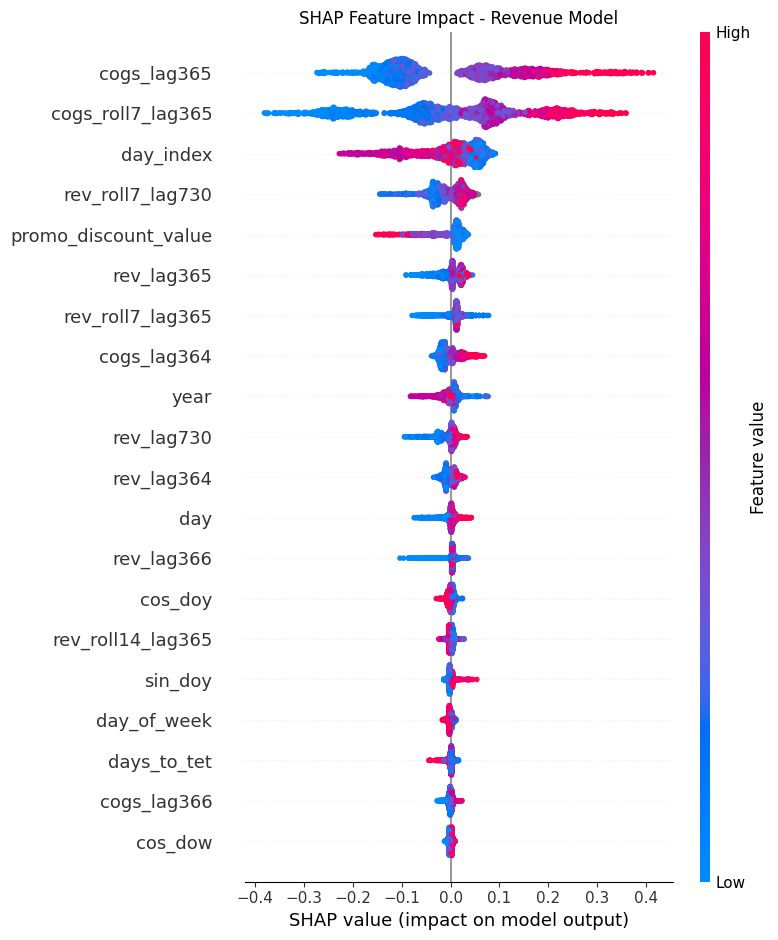

Saved: shap_bar_revenue.png & shap_beeswarm_revenue.png

Business Interpretation (top drivers):
  rev_lag365 / rev_roll*_lag365 → same-day last year is the strongest signal;
      captures annual seasonality + embedded trend.
  days_until_next_promo         → customers hold purchases before a promo;
      revenue dips ~14 days before a flash sale.
  is_promo_day / promo_discount_value → flash sales lift revenue significantly;
      higher discount → larger lift.
  day_of_week / sin_dow / cos_dow    → strong weekly cycle (weekends spike).
  days_to_tet / is_pre_tet           → pre-Tet surge (~3-4 weeks before Tet).
  day_index                          → long-term upward trend in revenue.



In [ ]:

# ── Cell 6: Save submission.csv + Feature Importance ─────────────────────────
sample_sub = pd.read_csv(SAMPLE_FILE, parse_dates=['Date'])

# Align to sample_submission order (do NOT sort/shuffle)
sub = sample_sub[['Date']].copy()
sub = sub.merge(pred_df, on='Date', how='left')

# Safety: clip negatives
sub['Revenue'] = sub['Revenue'].clip(lower=0)
sub['COGS']    = sub['COGS'].clip(lower=0)

# Verify no missing rows
missing = sub[['Revenue','COGS']].isnull().sum().sum()
print(f"Missing predictions : {missing}  (should be 0)")
print(f"Rows in submission  : {len(sub)}  (expected {len(sample_sub)})")

sub.to_csv(SUB_FILE, index=False, float_format='%.4f')
print(f"\nSaved → {SUB_FILE}")
print(sub.head(5).to_string(index=False))

# ── Feature Importance (Built-in) ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import shap

fi = (pd.DataFrame({'feature': FEATURE_COLS,
                    'importance': final_rev.feature_importances_})
        .sort_values('importance', ascending=False)
        .reset_index(drop=True))

print("\n── Top 25 Revenue Feature Importances ──────────────────────────────────")
print(fi.head(25).to_string(index=False))

# ── SHAP Analysis for Revenue Model ───────────────────────────────────────────
print("\n── Computing SHAP values for explainability ──────────────────────────────")
sample_size = min(2000, len(X_full))
X_shap_sample = X_full.sample(sample_size, random_state=SEED)

explainer = shap.TreeExplainer(final_rev)
shap_values = explainer.shap_values(X_shap_sample)

# Bar plot - feature importance
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, plot_type='bar', show=False, max_display=20)
plt.title('SHAP Feature Importance - Revenue Model')
plt.tight_layout()
plt.savefig(DATA_DIR + 'shap_bar_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

# Beeswarm plot - feature impact direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap_sample, show=False, max_display=20)
plt.title('SHAP Feature Impact - Revenue Model')
plt.tight_layout()
plt.savefig(DATA_DIR + 'shap_beeswarm_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

print('Saved: shap_bar_revenue.png & shap_beeswarm_revenue.png')

# ── Business interpretation ────────────────────────────────────────────────────
print("""
Business Interpretation (top drivers):
  rev_lag365 / rev_roll*_lag365 → same-day last year is the strongest signal;
      captures annual seasonality + embedded trend.
  days_until_next_promo         → customers hold purchases before a promo;
      revenue dips ~14 days before a flash sale.
  is_promo_day / promo_discount_value → flash sales lift revenue significantly;
      higher discount → larger lift.
  day_of_week / sin_dow / cos_dow    → strong weekly cycle (weekends spike).
  days_to_tet / is_pre_tet           → pre-Tet surge (~3-4 weeks before Tet).
  day_index                          → long-term upward trend in revenue.
""")


In [8]:

# # ── Cell 7: Quick Validation Plot ────────────────────────────────────────────
# import matplotlib.pyplot as plt

# val_dates = train_feat.loc[val_mask, 'Date'].values

# fig, axes = plt.subplots(2, 1, figsize=(15, 7), sharex=True)

# axes[0].plot(val_dates, y_val_rev.values,  lw=0.8, label='Actual',    color='steelblue')
# axes[0].plot(val_dates, val_pred_rev_lgb,       lw=0.8, label='Predicted (LGB)', color='tomato', alpha=0.8)
# axes[0].set_title('Revenue – Validation 2021-2022')
# axes[0].legend(); axes[0].set_ylabel('Revenue (VND)')

# axes[1].plot(val_dates, y_val_cogs.values,  lw=0.8, label='Actual',    color='steelblue')
# axes[1].plot(val_dates, val_pred_cogs_lgb,       lw=0.8, label='Predicted (LGB)', color='orange', alpha=0.8)
# axes[1].set_title('COGS – Validation 2021-2022')
# axes[1].legend(); axes[1].set_ylabel('COGS (VND)')

# plt.tight_layout()
# plt.savefig(DATA_DIR + 'validation_plot.png', dpi=120)
# plt.show()
# print("Plot saved → validation_plot.png")
